In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
img_emo_df = pd.read_csv("sdxl_generated_images.emotions.csv")

In [4]:
orig_df = pd.read_csv("diffusiondb-2m_random_10k-master-annotations.csv")

In [5]:
orig_df.columns

Index(['path', 'prompt', 'img_amusement', 'img_awe', 'img_contentment',
       'img_excitement', 'img_anger', 'img_disgust', 'img_fear', 'img_sadness',
       'text_amusement', 'text_surprise', 'text_joy', 'text_excitement',
       'text_anger', 'text_disgust', 'text_fear', 'text_sadness',
       'text_admiration', 'text_annoyance', 'text_approval', 'text_caring',
       'text_confusion', 'text_curiosity', 'text_desire',
       'text_disappointment', 'text_disapproval', 'text_embarrassment',
       'text_gratitude', 'text_grief', 'text_love', 'text_nervousness',
       'text_optimism', 'text_pride', 'text_realization', 'text_relief',
       'text_remorse'],
      dtype='object')

In [6]:
orig_df["img_id"] = orig_df["path"].apply(lambda s: int(s.rpartition("/")[-1].replace(".png","")))

In [7]:
img_emo_df["img_id_raw"] = img_emo_df["img_id"]
img_emo_df["img_id"] = img_emo_df["img_id"].apply(lambda s: int(s.replace("img.","")))

In [8]:
img_emo_df

,img_id,img_amusement,img_awe,img_contentment,img_excitement,img_anger,img_disgust,img_fear,img_sadness,img_id_raw
0,356,0.835477,0.009756,0.093765,0.006054,0.014005,0.019527,0.015092,0.006324,img.00000356
1,17,0.236748,0.039111,0.154255,0.030298,0.150876,0.017266,0.306853,0.064593,img.00000017
2,330,0.008903,0.002493,0.000795,0.002613,0.008723,0.006857,0.963974,0.005641,img.00000330
3,37,0.506355,0.172952,0.042539,0.033110,0.082612,0.113427,0.029351,0.019653,img.00000037
4,357,0.174440,0.038951,0.068776,0.136841,0.228063,0.017604,0.125206,0.210120,img.00000357
...,...,...,...,...,...,...,...,...,...,...
1666,8890,0.002992,0.013985,0.005632,0.015941,0.332516,0.001357,0.019968,0.607610,img.00008890
1667,8892,0.076681,0.005244,0.003065,0.014255,0.017634,0.003594,0.876437,0.003090,img.00008892
1668,8896,0.128414,0.137899,0.193036,0.221980,0.048480,0.035466,0.104271,0.130454,img.00008896
1669,8899,0.008407,0.689490,0.129029,0.078003,0.086077,0.000526,0.002288,0.006181,img.00008899


In [9]:
merged_df = img_emo_df.set_index("img_id").join(orig_df.set_index("img_id"), lsuffix="_sdxl")

In [10]:
merged_df

,img_amusement_sdxl,img_awe_sdxl,img_contentment_sdxl,img_excitement_sdxl,img_anger_sdxl,img_disgust_sdxl,img_fear_sdxl,img_sadness_sdxl,img_id_raw,path,...,text_embarrassment,text_gratitude,text_grief,text_love,text_nervousness,text_optimism,text_pride,text_realization,text_relief,text_remorse
img_id,,,,,,,,,,,,,,,,,,,,,
356,0.835477,0.009756,0.093765,0.006054,0.014005,0.019527,0.015092,0.006324,img.00000356,diffusiondb_images_2m_random_10k/356.png,...,0.000814,0.000293,0.000248,0.000458,0.000447,0.000500,0.000409,0.016377,0.000287,0.000254
17,0.236748,0.039111,0.154255,0.030298,0.150876,0.017266,0.306853,0.064593,img.00000017,diffusiondb_images_2m_random_10k/17.png,...,0.000618,0.000311,0.000306,0.000370,0.000317,0.000349,0.000422,0.002061,0.000279,0.000304
330,0.008903,0.002493,0.000795,0.002613,0.008723,0.006857,0.963974,0.005641,img.00000330,diffusiondb_images_2m_random_10k/330.png,...,0.000333,0.000242,0.000234,0.000241,0.000433,0.000310,0.000293,0.005015,0.000237,0.000227
37,0.506355,0.172952,0.042539,0.033110,0.082612,0.113427,0.029351,0.019653,img.00000037,diffusiondb_images_2m_random_10k/37.png,...,0.000394,0.000287,0.000250,0.000359,0.000247,0.000286,0.000330,0.000703,0.000254,0.000255
357,0.174440,0.038951,0.068776,0.136841,0.228063,0.017604,0.125206,0.210120,img.00000357,diffusiondb_images_2m_random_10k/357.png,...,0.001404,0.000355,0.000281,0.000393,0.000285,0.000382,0.000418,0.009515,0.000286,0.000284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8890,0.002992,0.013985,0.005632,0.015941,0.332516,0.001357,0.019968,0.607610,img.00008890,diffusiondb_images_2m_random_10k/8890.png,...,0.000398,0.000404,0.000242,0.110788,0.000249,0.000457,0.000374,0.010654,0.000233,0.000259
8892,0.076681,0.005244,0.003065,0.014255,0.017634,0.003594,0.876437,0.003090,img.00008892,diffusiondb_images_2m_random_10k/8892.png,...,0.000431,0.000871,0.000266,0.187579,0.000250,0.000346,0.000477,0.000962,0.000243,0.000267
8896,0.128414,0.137899,0.193036,0.221980,0.048480,0.035466,0.104271,0.130454,img.00008896,diffusiondb_images_2m_random_10k/8896.png,...,0.000701,0.000327,0.000234,0.000307,0.000275,0.000468,0.000377,0.025672,0.000229,0.000240


In [11]:
merged_df.columns

Index(['img_amusement_sdxl', 'img_awe_sdxl', 'img_contentment_sdxl',
       'img_excitement_sdxl', 'img_anger_sdxl', 'img_disgust_sdxl',
       'img_fear_sdxl', 'img_sadness_sdxl', 'img_id_raw', 'path', 'prompt',
       'img_amusement', 'img_awe', 'img_contentment', 'img_excitement',
       'img_anger', 'img_disgust', 'img_fear', 'img_sadness', 'text_amusement',
       'text_surprise', 'text_joy', 'text_excitement', 'text_anger',
       'text_disgust', 'text_fear', 'text_sadness', 'text_admiration',
       'text_annoyance', 'text_approval', 'text_caring', 'text_confusion',
       'text_curiosity', 'text_desire', 'text_disappointment',
       'text_disapproval', 'text_embarrassment', 'text_gratitude',
       'text_grief', 'text_love', 'text_nervousness', 'text_optimism',
       'text_pride', 'text_realization', 'text_relief', 'text_remorse'],
      dtype='object')

In [12]:
merged_df.to_csv("sdxl_generated_images.merged_emotions.csv")

In [13]:
img_emotion_cols = [
    'img_amusement', 'img_awe', 'img_contentment', 'img_excitement',
    'img_anger', 'img_disgust', 'img_fear', 'img_sadness'
]

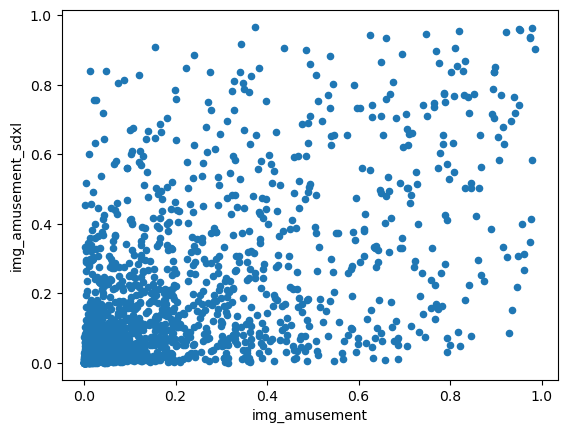

,img_amusement,img_amusement_sdxl
img_amusement,1.000000,0.571698
img_amusement_sdxl,0.571698,1.000000


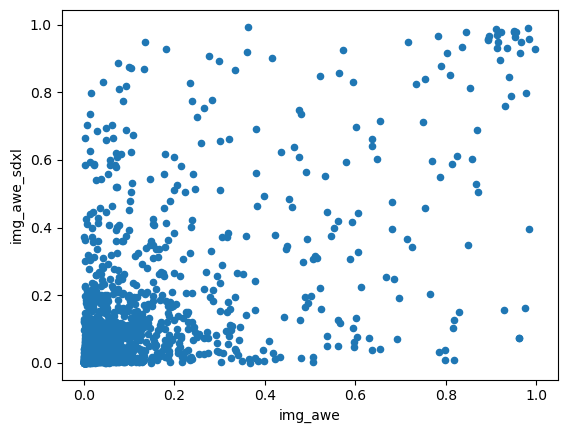

,img_awe,img_awe_sdxl
img_awe,1.00000,0.61294
img_awe_sdxl,0.61294,1.00000


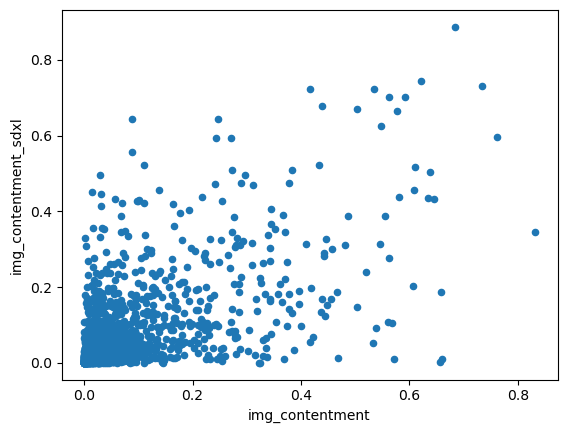

,img_contentment,img_contentment_sdxl
img_contentment,1.000000,0.613116
img_contentment_sdxl,0.613116,1.000000


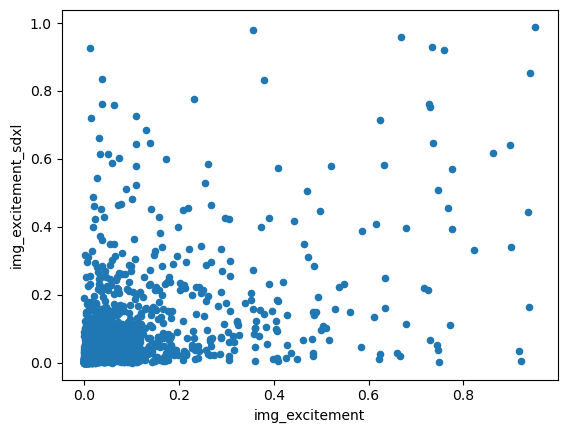

,img_excitement,img_excitement_sdxl
img_excitement,1.000000,0.481461
img_excitement_sdxl,0.481461,1.000000


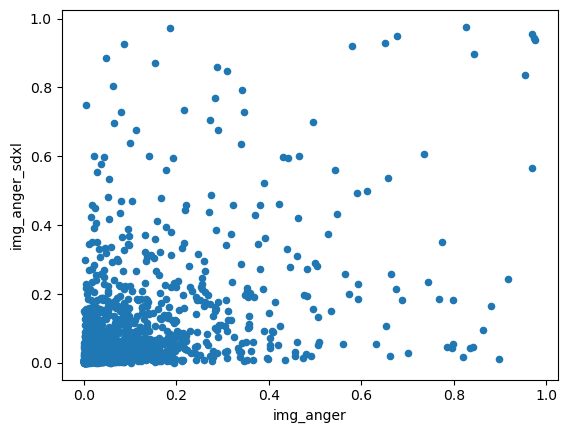

,img_anger,img_anger_sdxl
img_anger,1.000000,0.474595
img_anger_sdxl,0.474595,1.000000


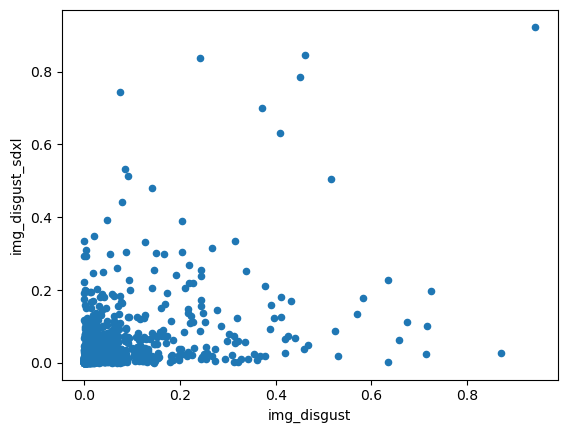

,img_disgust,img_disgust_sdxl
img_disgust,1.000000,0.443446
img_disgust_sdxl,0.443446,1.000000


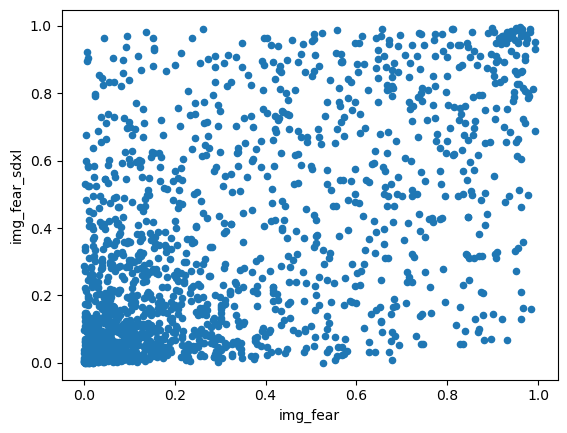

,img_fear,img_fear_sdxl
img_fear,1.000000,0.591379
img_fear_sdxl,0.591379,1.000000


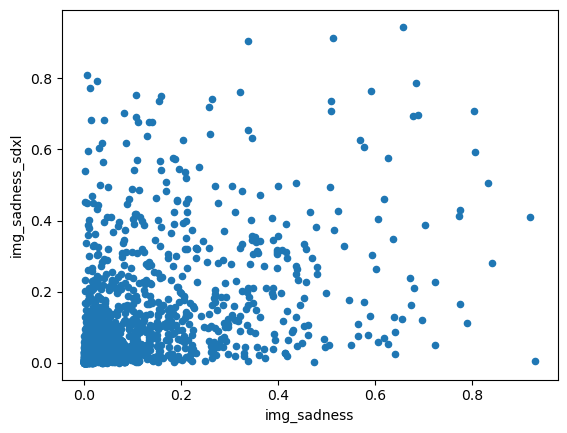

,img_sadness,img_sadness_sdxl
img_sadness,1.000000,0.459836
img_sadness_sdxl,0.459836,1.000000


In [15]:
for ec in img_emotion_cols:
    merged_df.plot.scatter(ec,ec+"_sdxl")
    plt.show()

    display(merged_df[[ec,ec+"_sdxl"]].corr())